# 7-Day Forecast V4 — 3-Model Comparison

Trains and compares **3 models** on the V4 dataset (5 years, 1,437 SKUs, 28 event features, no lag).
Uses date-based 5-fold cross-validation to check for overfitting before final test evaluation.

Pipeline: **MinMaxScaler → model** (scales all features to [0, 1]).

| Model | Notes |
|-------|-------|
| **LightGBM** | Gradient boosting — fast, handles tabular data well |
| **XGBoost** | Gradient boosting — alternative implementation |
| **Random Forest** | Bagged decision trees — robust baseline |

**V3 Baseline reference:** MAE=5.03, RMSE=10.33, SMAPE=67.4% (Optuna-tuned LGBM, 31 features, 1.5 yrs)

**Metrics:** MAE, RMSE, SMAPE, BIAS

## 1) Imports & Paths

In [20]:
from pathlib import Path
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

RANDOM_SEED = 42
ROOT     = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'processed' / '7_Day_Dataset'

print('Data dir:', DATA_DIR)

Data dir: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\data\processed\7_Day_Dataset


## 2) Load Data

In [21]:
train_df = pd.read_csv(DATA_DIR / 'train.csv', parse_dates=['date'])
val_df   = pd.read_csv(DATA_DIR / 'val.csv',   parse_dates=['date'])
test_df  = pd.read_csv(DATA_DIR / 'test.csv',  parse_dates=['date'])

# train+val combined — used for cross-validation only (test never touched during CV)
tv_df = pd.concat([train_df, val_df]).sort_values('date').reset_index(drop=True)

print(f'Train : {len(train_df):,} rows | {train_df["date"].min().date()} to {train_df["date"].max().date()}')
print(f'Val   : {len(val_df):,}   rows | {val_df["date"].min().date()} to {val_df["date"].max().date()}')
print(f'Test  : {len(test_df):,}  rows | {test_df["date"].min().date()} to {test_df["date"].max().date()}')
print(f'TV    : {len(tv_df):,} rows (train+val for CV)')

Train : 274,467 rows | 2011-01-29 to 2014-09-20
Val   : 58,917   rows | 2014-09-27 to 2015-07-04
Test  : 60,354  rows | 2015-07-11 to 2016-04-23
TV    : 333,384 rows (train+val for CV)


## 3) Features & Target

In [22]:
TARGET = 'aggregated_sales_7'
DROP   = [TARGET, 'item_id', 'date']   # drop raw string item_id

# Label-encode item_id → item_enc (integer 0..N-1)
# Build map from training SKUs only, then apply to all splits
all_skus = sorted(train_df['item_id'].unique())
sku_map  = {sku: i for i, sku in enumerate(all_skus)}

for df in [train_df, val_df, test_df, tv_df]:
    df['item_enc'] = df['item_id'].map(sku_map).astype(int)

# FEATURES = all columns except DROP + the encoded item column
FEATURES = [c for c in train_df.columns if c not in DROP] + ['item_enc']

X_train = train_df[FEATURES];  y_train = train_df[TARGET]
X_val   = val_df[FEATURES];    y_val   = val_df[TARGET]
X_test  = test_df[FEATURES];   y_test  = test_df[TARGET]

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'Encoded {len(all_skus)} SKUs → item_enc range 0..{len(all_skus)-1}')

Features (33): ['is_month_end', 'aggregated_sell_price', 'snap_ca', 'event_christmas_7', 'event_easter_7', 'event_eid_al_fitr_7', 'event_eid_al_adha_7', 'event_fathers_day_7', 'event_halloween_7', 'event_mothers_day_7', 'event_newyear_7', 'event_orthodox_christmas_7', 'event_orthodox_easter_7', 'event_ramadan_starts_7', 'event_thanksgiving_7', 'event_valentines_day_7', 'event_superbowl_7', 'event_independence_day_7', 'event_memorial_day_7', 'event_labor_day_7', 'event_mlk_day_7', 'event_presidents_day_7', 'event_columbus_day_7', 'event_veterans_day_7', 'event_st_patricks_day_7', 'event_cinco_de_mayo_7', 'event_chanukah_7', 'event_lent_start_7', 'event_lent_week2_7', 'event_pesach_end_7', 'event_purim_end_7', 'item_enc', 'item_enc']
Encoded 1437 SKUs → item_enc range 0..1436


## 4) Metric Helpers & Pipeline Factory

In [23]:
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)))

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        'MAE':   round(float(mean_absolute_error(y_true, y_pred)), 4),
        'RMSE':  round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        'SMAPE': round(smape(y_true, y_pred), 4),
        'BIAS':  round(float(np.mean(y_pred - y_true)), 4),
    }

def make_pipeline(model):
    """Scale → model. MinMaxScaler maps all features to [0, 1]."""
    return Pipeline([
        ('scale', MinMaxScaler()),
        ('model', model),
    ])

print('Helpers ready.')

Helpers ready.


## 5) Define All 3 Models

In [24]:
MODELS = {
    'LightGBM': make_pipeline(LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=31,
        subsample=0.9, colsample_bytree=0.9,
        random_state=RANDOM_SEED, verbose=-1,
    )),
    'XGBoost': make_pipeline(XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=1.0,
        objective='reg:squarederror', tree_method='hist',
        random_state=RANDOM_SEED, verbosity=0,
    )),
    'Random Forest': make_pipeline(RandomForestRegressor(
        n_estimators=200, min_samples_leaf=5,
        n_jobs=-1, random_state=RANDOM_SEED,
    )),
}

print('Models defined:', list(MODELS.keys()))

Models defined: ['LightGBM', 'XGBoost', 'Random Forest']


## 6) Cross-Validation (date-based TimeSeriesSplit, 5 folds)

Splits on **unique dates** — all items in a given week always stay in the same fold.
This respects temporal order and prevents future data leaking into training.
**Test data is never touched here.**

In [25]:
def run_cv(df, pipeline, n_splits=5):
    dates = np.array(sorted(df['date'].unique()))
    tscv  = TimeSeriesSplit(n_splits=n_splits)
    folds = []
    for fold, (tr_idx, va_idx) in enumerate(tscv.split(dates), 1):
        tr = df[df['date'].isin(set(dates[tr_idx]))]
        va = df[df['date'].isin(set(dates[va_idx]))]
        pipe = copy.deepcopy(pipeline)
        pipe.fit(tr[FEATURES], tr[TARGET])
        m = compute_metrics(va[TARGET].values, pipe.predict(va[FEATURES]))
        m['fold'] = fold
        folds.append(m)
        print(f'  fold {fold}: MAE={m["MAE"]:.4f}  SMAPE={m["SMAPE"]:.2f}%  BIAS={m["BIAS"]:.4f}')
    return folds


cv_results = {}
for name, pipeline in MODELS.items():
    print(f'\n--- CV: {name} ---')
    cv_results[name] = run_cv(tv_df, pipeline)

print('\nCV complete.')


--- CV: LightGBM ---


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  fold 1: MAE=10.7484  SMAPE=128.57%  BIAS=-3.2874


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  fold 2: MAE=9.8459  SMAPE=119.52%  BIAS=-1.2185


...

  fold 3: MAE=10.6017  SMAPE=110.01%  BIAS=-2.5510


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  fold 4: MAE=10.6789  SMAPE=98.38%  BIAS=-1.9308


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  fold 5: MAE=10.0694  SMAPE=87.56%  BIAS=-1.1558

--- CV: XGBoost ---
  fold 1: MAE=10.8064  SMAPE=128.97%  BIAS=-3.6016
  fold 2: MAE=10.0038  SMAPE=120.26%  BIAS=-1.2224
  fold 3: MAE=11.0360  SMAPE=111.26%  BIAS=-2.5093
  fold 4: MAE=10.9227  SMAPE=100.33%  BIAS=-2.0423
  fold 5: MAE=10.2681  SMAPE=89.40%  BIAS=-1.3112

--- CV: Random Forest ---
  fold 1: MAE=8.4067  SMAPE=85.59%  BIAS=-3.3950
  fold 2: MAE=7.8434  SMAPE=79.26%  BIAS=-0.4047
  fold 3: MAE=9.1197  SMAPE=90.14%  BIAS=-2.2024
  fold 4: MAE=9.5300  SMAPE=92.47%  BIAS=-1.6616
  fold 5: MAE=8.8901  SMAPE=88.79%  BIAS=-0.2809

CV complete.


## 7) CV Summary Table

In [26]:
cv_summary_rows = []
for name, folds in cv_results.items():
    fd = pd.DataFrame(folds)
    cv_summary_rows.append({
        'model':          name,
        'CV_MAE_mean':   round(fd['MAE'].mean(),   4),
        'CV_MAE_std':    round(fd['MAE'].std(),    4),
        'CV_RMSE_mean':  round(fd['RMSE'].mean(),  4),
        'CV_SMAPE_mean': round(fd['SMAPE'].mean(), 4),
        'CV_SMAPE_std':  round(fd['SMAPE'].std(),  4),
        'CV_BIAS_mean':  round(fd['BIAS'].mean(),  4),
    })

cv_summary = pd.DataFrame(cv_summary_rows).sort_values('CV_MAE_mean').reset_index(drop=True)
print('=== Cross-Validation Summary (5 folds, sorted by mean MAE) ===')
print(cv_summary.to_string(index=False))

=== Cross-Validation Summary (5 folds, sorted by mean MAE) ===
        model  CV_MAE_mean  CV_MAE_std  CV_RMSE_mean  CV_SMAPE_mean  CV_SMAPE_std  CV_BIAS_mean
Random Forest       8.7580      0.6527       24.0041        87.2501        5.1140       -1.5889
     LightGBM      10.3889      0.4048       25.4559       108.8078       16.3326       -2.0287
      XGBoost      10.6074      0.4478       25.5412       110.0458       15.6910       -2.1374


## 8) Train on Full Train Set — Evaluate Val & Test

Each model trained on `train_df` only, evaluated on val and test separately.
Comparing CV mean vs test score reveals generalisation.

In [27]:
trained = {}
final_rows = []

for name, pipeline in MODELS.items():
    print(f'Training {name}...')
    pipe = copy.deepcopy(pipeline)
    pipe.fit(X_train, y_train)
    trained[name] = pipe

    p_val  = pipe.predict(X_val)
    p_test = pipe.predict(X_test)

    cv_mae   = next(r['CV_MAE_mean']   for r in cv_summary_rows if r['model'] == name)
    cv_smape = next(r['CV_SMAPE_mean'] for r in cv_summary_rows if r['model'] == name)

    for split, y_true, y_pred in [('val', y_val, p_val), ('test', y_test, p_test)]:
        m = compute_metrics(y_true.values, y_pred)
        final_rows.append({'model': name, 'split': split,
                           'CV_MAE_mean': cv_mae, 'CV_SMAPE_mean': cv_smape, **m})

print('\nAll models trained.')

Training LightGBM...


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Training XGBoost...
Training Random Forest...

All models trained.


## 9) Full Comparison Table + Side-by-Side Bar Charts

=== TEST SET RESULTS (sorted by MAE) ===
        model     MAE    RMSE   SMAPE    BIAS
Random Forest  9.6838 20.9484 94.9142 -0.0021
     LightGBM  9.8271 19.9308 87.7250 -0.7530
      XGBoost 10.2491 20.7659 90.3601 -0.7684

=== VAL SET RESULTS (sorted by MAE) ===
        model     MAE    RMSE   SMAPE    BIAS
Random Forest  8.9632 20.3971 88.9342 -0.4372
     LightGBM  9.9958 21.4162 87.3642 -1.0266
      XGBoost 10.2737 22.3001 89.4637 -1.4358

--- V3 Baseline (reference: Optuna-tuned LGBM, 31 features, 1.5 yrs) ---
  Val : MAE=4.9602  RMSE=10.8250  SMAPE=75.68%  BIAS=0.2025
  Test: MAE=5.0345  RMSE=10.3317  SMAPE=67.39%  BIAS=0.1945


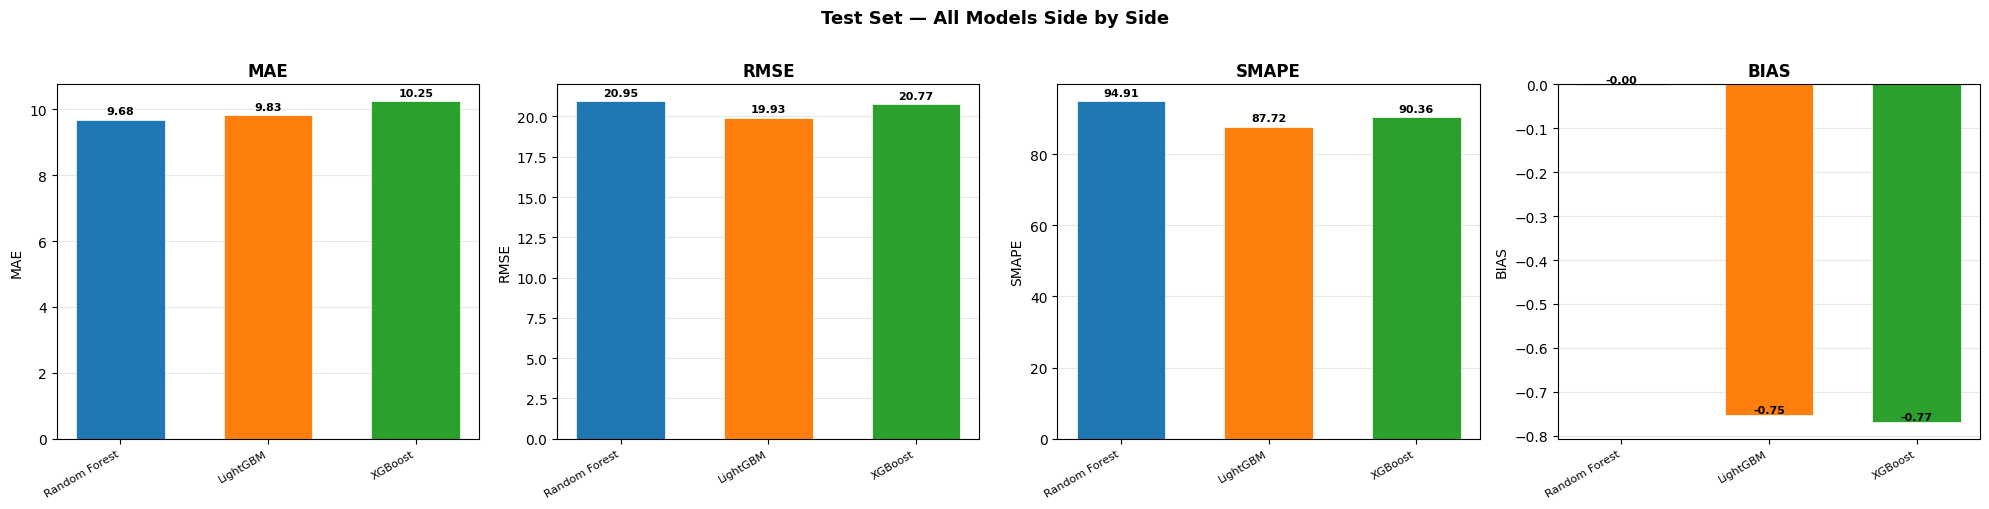

In [28]:
results_df = pd.DataFrame(final_rows)

# ── Text tables ────────────────────────────────────────────────────────────────
print('=== TEST SET RESULTS (sorted by MAE) ===')
test_res = results_df[results_df['split'] == 'test'].sort_values('MAE')
print(test_res[['model', 'MAE', 'RMSE', 'SMAPE', 'BIAS']].to_string(index=False))

print()
print('=== VAL SET RESULTS (sorted by MAE) ===')
val_res = results_df[results_df['split'] == 'val'].sort_values('MAE')
print(val_res[['model', 'MAE', 'RMSE', 'SMAPE', 'BIAS']].to_string(index=False))

print()
print('--- V3 Baseline (reference: Optuna-tuned LGBM, 31 features, 1.5 yrs) ---')
print('  Val : MAE=4.9602  RMSE=10.8250  SMAPE=75.68%  BIAS=0.2025')
print('  Test: MAE=5.0345  RMSE=10.3317  SMAPE=67.39%  BIAS=0.1945')

# ── Side-by-side bar charts ────────────────────────────────────────────────────
metrics   = ['MAE', 'RMSE', 'SMAPE', 'BIAS']
models    = test_res['model'].tolist()
colors    = plt.cm.tab10.colors[:len(models)]
x         = np.arange(len(models))
bar_width = 0.6

fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5))
fig.suptitle('Test Set — All Models Side by Side', fontsize=13, fontweight='bold', y=1.01)

for ax, metric in zip(axes, metrics):
    values = test_res[metric].tolist()
    bars   = ax.bar(x, values, width=bar_width, color=colors, edgecolor='white', linewidth=0.5)
    # Value label on top of each bar
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(values) * 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel(metric)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 10) Overfitting Check — CV SMAPE vs Test SMAPE

Small gap = model generalises. Large positive gap = overfitting.

In [29]:
overfit = test_res[['model', 'CV_SMAPE_mean', 'SMAPE']].copy()
overfit['gap (test - CV)'] = (overfit['SMAPE'] - overfit['CV_SMAPE_mean']).round(4)
print('=== Overfitting Check (sorted by gap) ===')
print(overfit.sort_values('gap (test - CV)').to_string(index=False))

=== Overfitting Check (sorted by gap) ===
        model  CV_SMAPE_mean   SMAPE  gap (test - CV)
     LightGBM       108.8078 87.7250         -21.0828
      XGBoost       110.0458 90.3601         -19.6857
Random Forest        87.2501 94.9142           7.6641


## 11) Actual vs Predicted — Test Set (daily average)

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


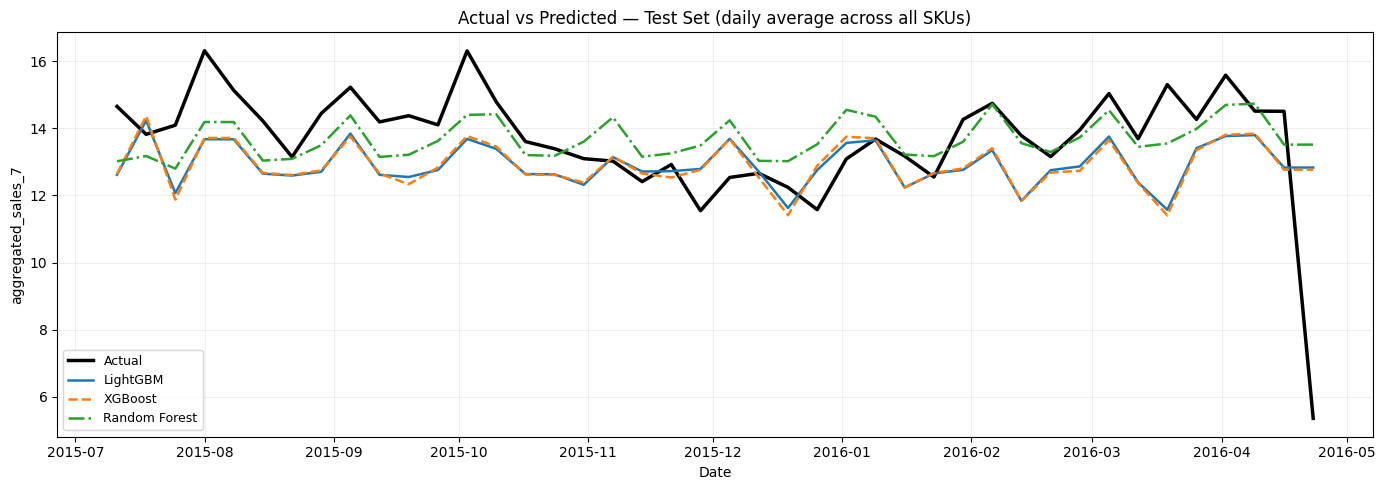

In [30]:
plot_df = test_df[['date']].copy()
plot_df['Actual'] = y_test.values
for name, pipe in trained.items():
    plot_df[name] = pipe.predict(X_test)

daily = plot_df.groupby('date', as_index=False).mean(numeric_only=True).sort_values('date')

styles = ['-', '--', '-.', ':', (0,(3,1,1,1))]
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily['date'], daily['Actual'], label='Actual', color='black', linewidth=2.5)
for i, name in enumerate(trained):
    ax.plot(daily['date'], daily[name], label=name, linewidth=1.8, linestyle=styles[i % len(styles)])
ax.set_title('Actual vs Predicted — Test Set (daily average across all SKUs)')
ax.set_xlabel('Date')
ax.set_ylabel('aggregated_sales_7')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 12) Residual Distributions — Test Set

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


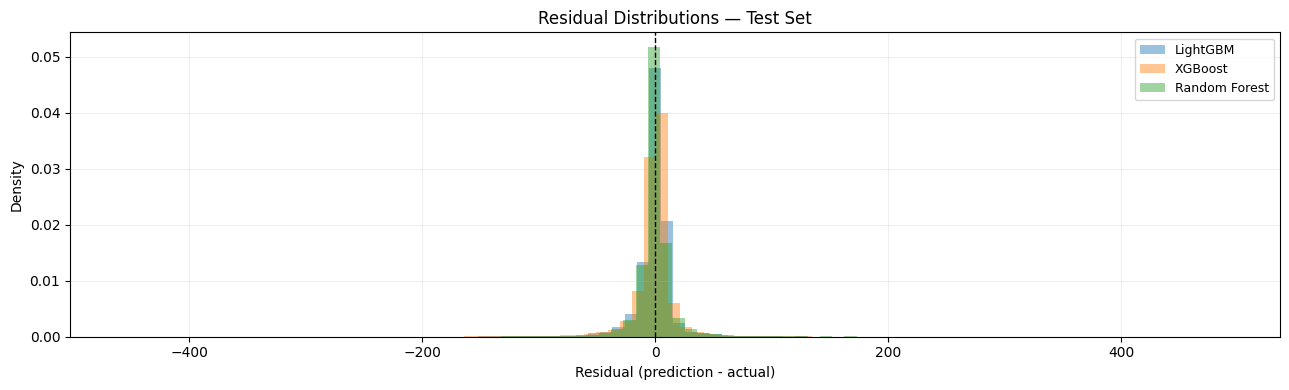

In [31]:
fig, ax = plt.subplots(figsize=(13, 4))
for name, pipe in trained.items():
    res = pipe.predict(X_test) - y_test.values
    ax.hist(res, bins=80, alpha=0.45, density=True, label=name)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Residual Distributions — Test Set')
ax.set_xlabel('Residual (prediction - actual)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 13) Feature Importance — Tree-Based Models

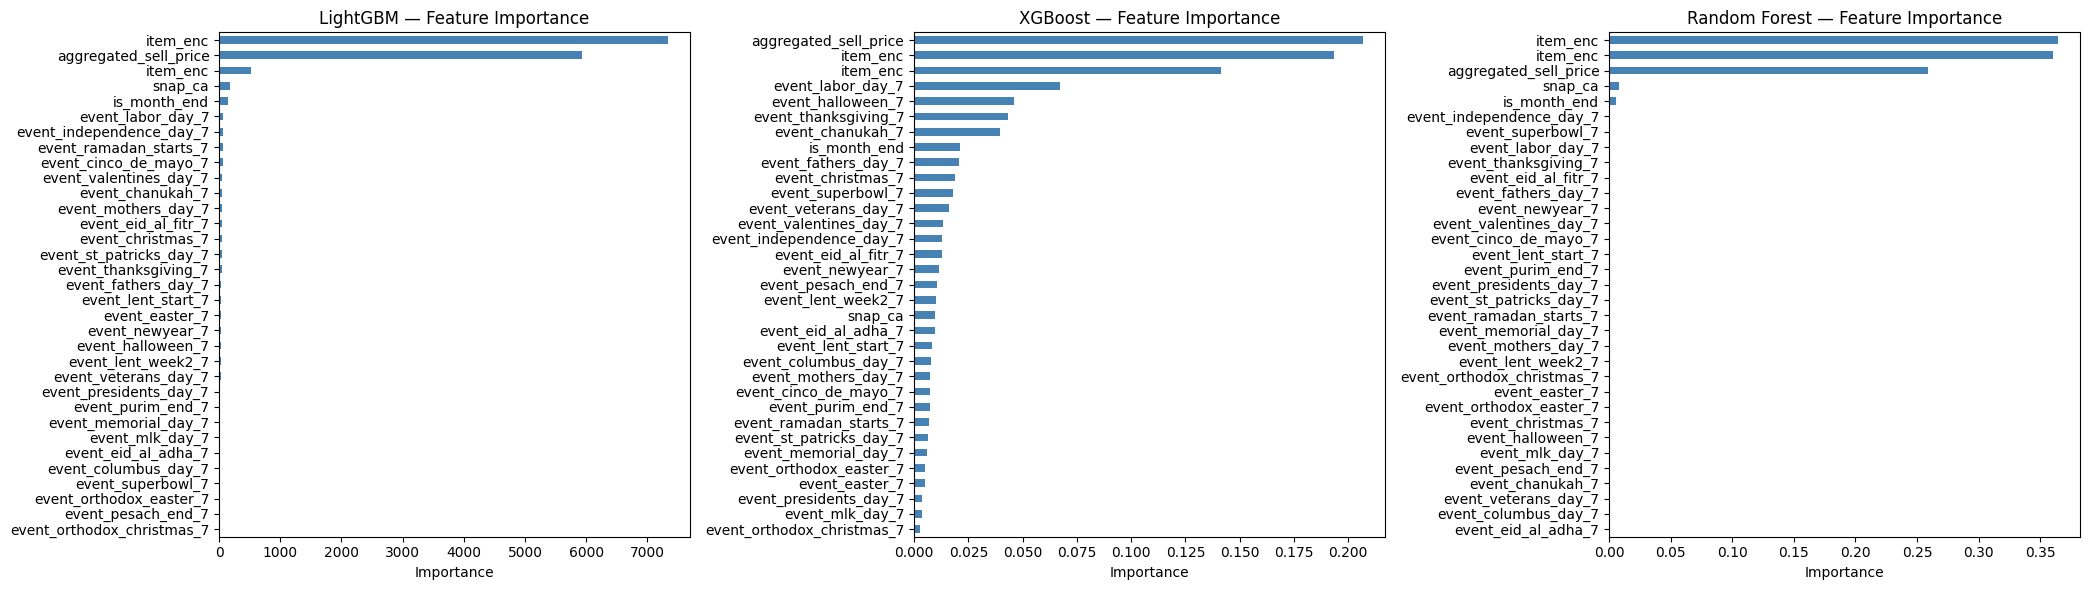

In [32]:
tree_models = {n: p for n, p in trained.items() if n in ('LightGBM', 'XGBoost', 'Random Forest')}

fig, axes = plt.subplots(1, len(tree_models), figsize=(7 * len(tree_models), 6))
for ax, (name, pipe) in zip(axes, tree_models.items()):
    fi = pd.Series(
        pipe.named_steps['model'].feature_importances_,
        index=FEATURES
    ).sort_values(ascending=True)
    fi.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name} — Feature Importance')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 14) Single-SKU Deep Dive — FOODS_3_090 (Test Set)

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


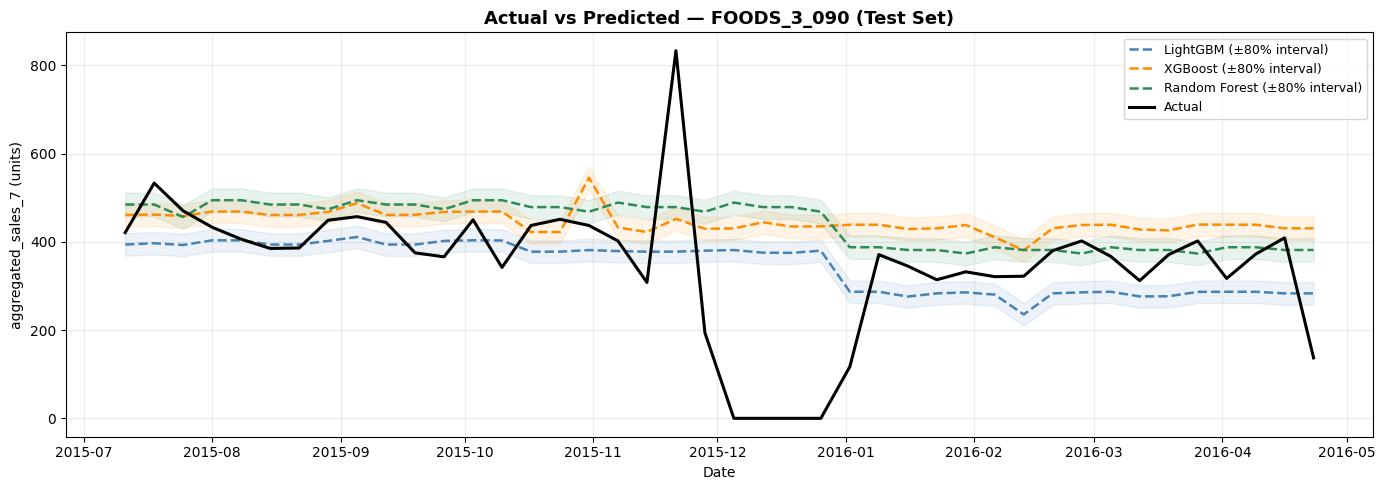


=== Metrics for FOODS_3_090 — Test Set ===
  LightGBM         MAE=106.74  RMSE=156.03  SMAPE=39.5%  BIAS=-1.24
  XGBoost          MAE=122.44  RMSE=178.04  SMAPE=40.2%  BIAS=+98.27
  Random Forest    MAE=118.25  RMSE=183.17  SMAPE=38.2%  BIAS=+94.37


In [34]:
SKU = 'FOODS_3_090'

# ── Filter test rows for this SKU ─────────────────────────────────────────────
sku_test = test_df[test_df['item_id'] == SKU].copy().sort_values('date').reset_index(drop=True)
X_sku    = sku_test[FEATURES]
y_sku    = sku_test[TARGET].values
dates    = sku_test['date'].values

# ── Predictions + per-model residual std from full test set ───────────────────
preds      = {name: pipe.predict(X_sku) for name, pipe in trained.items()}
resid_stds = {name: (pipe.predict(X_test) - y_test.values).std() for name, pipe in trained.items()}

colors_map = {'LightGBM': 'steelblue', 'XGBoost': 'darkorange', 'Random Forest': 'seagreen'}

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# Shaded 80% interval per model
for name, pred in preds.items():
    std   = resid_stds[name]
    upper = pred + 1.282 * std
    lower = np.maximum(0, pred - 1.282 * std)
    ax.fill_between(dates, lower, upper, alpha=0.10, color=colors_map[name])

# Model predictions
for name, pred in preds.items():
    ax.plot(dates, pred, label=f'{name} (±80% interval)',
            color=colors_map[name], linewidth=1.8, linestyle='--')

# Actual
ax.plot(dates, y_sku, label='Actual', color='black', linewidth=2.2)

ax.set_title(f'Actual vs Predicted — {SKU} (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('aggregated_sales_7 (units)')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ── Per-model metrics for this SKU ────────────────────────────────────────────
print(f'\n=== Metrics for {SKU} — Test Set ===')
for name, pred in preds.items():
    m = compute_metrics(y_sku, pred)
    print(f"  {name:15s}  MAE={m['MAE']:.2f}  RMSE={m['RMSE']:.2f}  SMAPE={m['SMAPE']:.1f}%  BIAS={m['BIAS']:+.2f}")